# F1130W JWST/MIRI Imaging Pipeline — SMC-SW-Bar-3 (GO-5952)

Custom data reduction for JWST/MIRI F1130W (11.3 µm) imaging.

WCS alignment uses shifts measured from F560W (see `F560W_pipeline.ipynb`).

**Pipeline:** Stage 1 → fix_rateints → Stage 2 → apply F560W shifts → Lyot flag → Stage 3

## 1. Configuration

In [1]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════

# ─── Target ───────────────────────────────────────────────
FILT           = 'F1130W'
TARGET         = 'SMC-SW-Bar-3'
PROGRAM        = 'GO-5952'

# ─── Paths ────────────────────────────────────────────────
BASE_DIR       = '/Users/melyajou/SMC_GO5952/miri'
TILE1_BASE     = 'jw05952003001'
TILE2_BASE     = 'jw05952003002'

# ─── WCS shifts (from F560W tweakreg) ────────────────────
TILE1_SHIFTS   = [-0.1674, -0.1364]
TILE2_SHIFTS   = [-0.1584, -0.1352]

# ─── Lyot coronagraph artifact ───────────────────────────
LYOT_ROW       = 700
LYOT_COL       = 310

# ─── Stage 1 options ─────────────────────────────────────
IPC_SKIP       = True       # skip IPC correction (Karl's practice)
JUMP_THRESHOLD = 5.0        # sigma for jump detection (MAST uses 4.0)

# ─── Run flags ────────────────────────────────────────────
run_detector1  = False       # Stage 1: detector1 + fix_rateints
run_image2     = True       # Stage 2: image2 calibration
run_image3     = True       # Stage 3: final mosaic

# ─── Stage 3 options ─────────────────────────────────────
TWEAKREG       = False      # skip — F560W shifts applied above
SKYMATCH       = False       # match sky levels between exposures
SKY_SUBTRACT   = False      # offset only, do not subtract
OUTLIER_DET    = True
PIXEL_SCALE    = 0.11       # arcsec/pix
PIXFRAC        = 1.0
KERNEL         = 'square'

# ─── Figures ─────────────────────────────────────────────
CMAP           = 'afmhot'
FIG_DPI        = 200

## 2. Setup

In [2]:
import os, sys, glob, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import logging

logging.getLogger('stpipe').setLevel(logging.WARNING)
logging.getLogger('CRDS').setLevel(logging.WARNING)

os.environ['CRDS_PATH']       = '/Users/melyajou/SMC_GO5952/crds_cache'
os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, sigma_clip
from jwst import datamodels
from jwst.datamodels import dqflags
from jwst.pipeline import calwebb_detector1, calwebb_image2, calwebb_image3
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base

sys.path.insert(0, '..')
from pipeline_utils import *

# Directories
stage0   = f'{BASE_DIR}/{FILT}/stage0'
stage1   = f'{BASE_DIR}/{FILT}/stage1'
stage2   = f'{BASE_DIR}/{FILT}/stage2'
stage3   = f'{BASE_DIR}/{FILT}/stage3'
fig_dir  = f'{BASE_DIR}/{FILT}/figures'
mast_dir = f'{BASE_DIR}/{FILT}/mast_reference'

for d in [stage0, stage1, stage2, stage3, fig_dir]:
    os.makedirs(d, exist_ok=True)

print(f'{TARGET} ({PROGRAM}) — {FILT}')

SMC-SW-Bar-3 (GO-5952) — F1130W


## 3. Stage 1 — Detector1 + fix_rateints

In [3]:
uncal_files = sorted(glob.glob(f'{stage0}/*_uncal.fits'))
print(f'{len(uncal_files)} uncal files')

if run_detector1:
    fixed_rate_files = run_stage1(uncal_files, stage1, IPC_SKIP, JUMP_THRESHOLD, TILE1_BASE)
else:
    print('Skipping Stage 1 (run_detector1 = False)')
    fixed_rate_files = sorted(glob.glob(f'{stage1}/*_fixed_rate.fits'))
    print(f'{len(fixed_rate_files)} fixed_rate files ready')

8 uncal files
Skipping Stage 1 (run_detector1 = False)
8 fixed_rate files ready


## 4. Stage 2 — Image2

In [4]:
if run_image2:
    cal_files = run_stage2(fixed_rate_files, stage2)
else:
    print('Skipping Stage 2 (run_image2 = False)')
    cal_files = sorted(glob.glob(f'{stage2}/*_cal.fits'))
    print(f'{len(cal_files)} cal files ready')

Running Stage 2 on 8 files...
  [1/8] jw05952003001_08101_00001_mirimage_fixed_rate.fits


2026-03-30 15:11:48,336 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-resamplestep_0001.asdf
2026-03-30 15:11:48,343 - stpipe.pipeline - INFO - PARS-IMAGE2PIPELINE parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-image2pipeline_0004.asdf
2026-03-30 15:11:48,350 - stpipe.step - INFO - Image2Pipeline instance created.
2026-03-30 15:11:48,351 - stpipe.step - INFO - BackgroundStep instance created.
2026-03-30 15:11:48,352 - stpipe.step - INFO - AssignWcsStep instance created.
2026-03-30 15:11:48,352 - stpipe.step - INFO - FlatFieldStep instance created.
2026-03-30 15:11:48,353 - stpipe.step - INFO - PhotomStep instance created.
2026-03-30 15:11:48,353 - stpipe.step - INFO - ResampleStep instance created.
2026-03-30 15:11:48,422 - stpipe.step - INFO - Step Image2Pipeline running with args ('/Users/melyajou/SMC_GO5952/miri/F1130W/stage1/jw05952003001_08101_00001_m

  [2/8] jw05952003001_08101_00002_mirimage_fixed_rate.fits


2026-03-30 15:11:49,563 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1130W/stage2/jw05952003001_08101_00002_mirimage_fixed_image2pipeline.fits>,).
2026-03-30 15:11:49,624 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-30 15:11:49,653 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.388478195 -73.365667475 11.283438440 -73.374315520 11.313614538 -73.404525113 11.419277191 -73.396125828
2026-03-30 15:11:49,654 - jwst.assig

  [3/8] jw05952003001_08101_00003_mirimage_fixed_rate.fits


...

  [7/8] jw05952003002_08101_00003_mirimage_fixed_rate.fits


2026-03-30 15:11:53,776 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1130W/stage2/jw05952003002_08101_00003_mirimage_fixed_image2pipeline.fits>,).
2026-03-30 15:11:53,835 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-30 15:11:53,865 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.373372059 -73.352260346 11.268407299 -73.360901106 11.298534175 -73.391112768 11.404121025 -73.382720824
2026-03-30 15:11:53,866 - jwst.assig

  [8/8] jw05952003002_08101_00004_mirimage_fixed_rate.fits


2026-03-30 15:11:54,695 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(1024, 1032) from /Users/melyajou/SMC_GO5952/miri/F1130W/stage2/jw05952003002_08101_00004_mirimage_fixed_image2pipeline.fits>,).
2026-03-30 15:11:54,756 - jwst.assign_wcs.miri - INFO - Created a MIRI mir_image pipeline with references {'distortion': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_distortion_0047.asdf', 'filteroffset': '/Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_filteroffset_0008.asdf', 'specwcs': None, 'regions': None, 'wavelengthrange': None, 'camera': None, 'collimator': None, 'disperser': None, 'fore': None, 'fpa': None, 'msa': None, 'ote': None, 'ifupost': None, 'ifufore': None, 'ifuslicer': None}
2026-03-30 15:11:54,787 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  11.360624517 -73.352591858 11.255651224 -73.361226117 11.285755807 -73.391439644 11.391351052 -73.383054240
2026-03-30 15:11:54,788 - jwst.assig

8 cal files ready


## 5. Apply F560W WCS Shifts

F560W has the most point sources for tweakreg. We reuse those shifts for all other filters.

In [5]:
wcs_cal_files = apply_tile_shifts(cal_files, TILE1_SHIFTS, TILE2_SHIFTS, TILE1_BASE)

Applying shifts:
  T1: [-0.1674, -0.1364]
  T2: [-0.1584, -0.1352]

  T1: jw05952003001_08101_00001_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_08101_00002_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_08101_00003_mirimage_fixed_wcs_cal.fits
  T1: jw05952003001_08101_00004_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_08101_00001_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_08101_00002_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_08101_00003_mirimage_fixed_wcs_cal.fits
  T2: jw05952003002_08101_00004_mirimage_fixed_wcs_cal.fits

8 WCS-corrected cal files


## 6. Lyot Flag + Stage 3 — Final Mosaic

In [6]:
for f in wcs_cal_files:
    flag_lyot(f, lyot_row=LYOT_ROW, lyot_col=LYOT_COL)
print(f'Lyot flagged in {len(wcs_cal_files)} files')

Lyot flagged in 8 files


In [7]:
if run_image3:
    mosaic = run_stage3(
        wcs_cal_files, f'miri_{FILT}_final', stage3,
        tweakreg=TWEAKREG, skymatch=SKYMATCH, sky_subtract=SKY_SUBTRACT,
        outlier_det=OUTLIER_DET, pixel_scale=PIXEL_SCALE,
        pixfrac=PIXFRAC, kernel=KERNEL)
else:
    print('Skipping Stage 3 (run_image3 = False)')
    mosaic = sorted(glob.glob(f'{stage3}/*_i2d.fits'))[0]

print(f'Mosaic: {mosaic}')

/Users/melyajou/miniforge3/envs/jwst/lib/python3.11/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)
2026-03-30 15:11:58,515 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-tweakregstep_0011.asdf
2026-03-30 15:11:58,523 - stpipe.step - INFO - PARS-OUTLIERDETECTIONSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-outlierdetectionstep_0097.asdf
2026-03-30 15:11:58,528 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pars-resamplestep_0001.asdf
2026-03-30 15:11:58,533 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/melyajou/SMC_GO5952/crds_cache/references/jwst/miri/jwst_miri_pa

Mosaic: /Users/melyajou/SMC_GO5952/miri/F1130W/stage3/miri_F1130W_final_i2d.fits


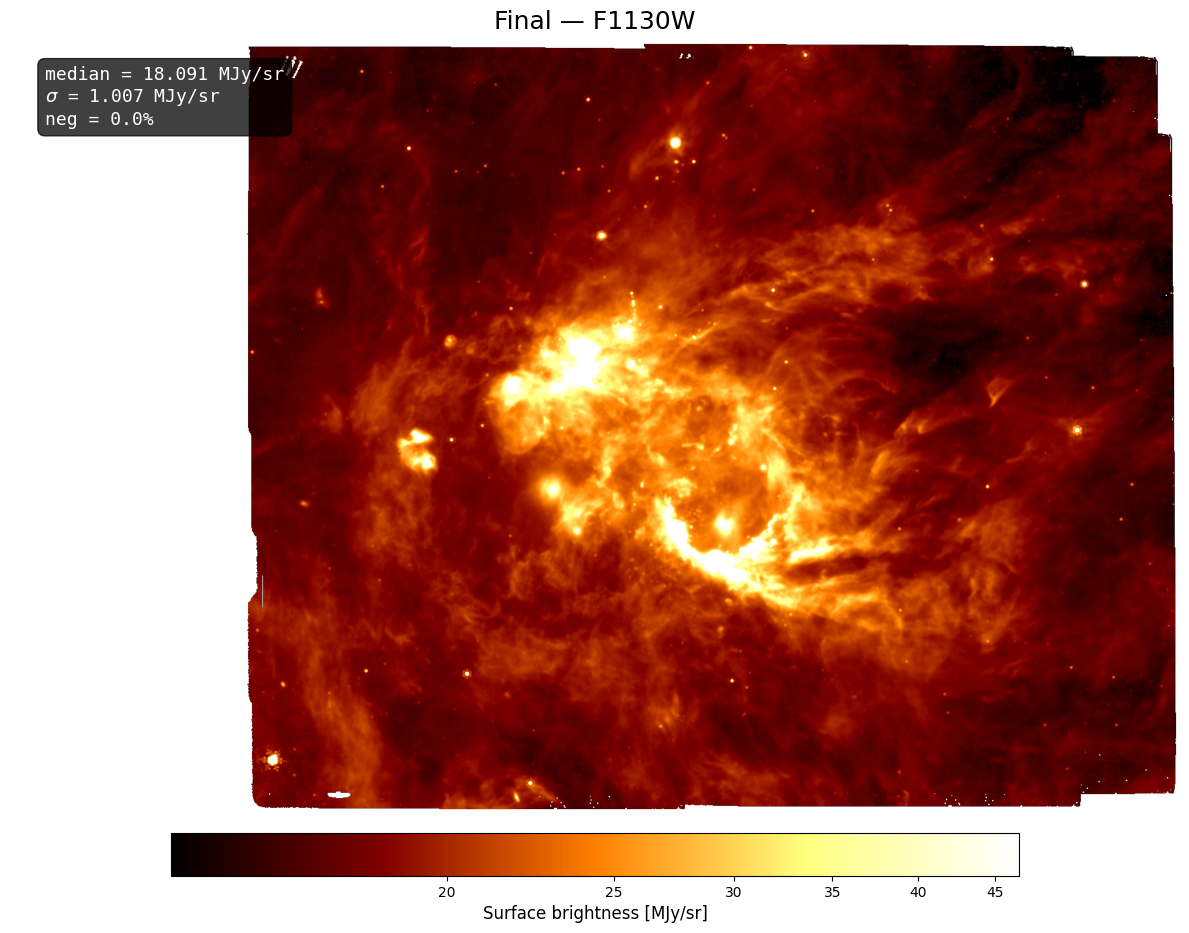

In [8]:
final_sci = load_mosaic(mosaic)
m_ours = get_stats(final_sci)
plot_mosaic(final_sci, f'Final — {FILT}', f'{FILT}_final.png',
            fig_dir=fig_dir, stats_txt=stats_label(*m_ours))

## 7. Comparison with MAST

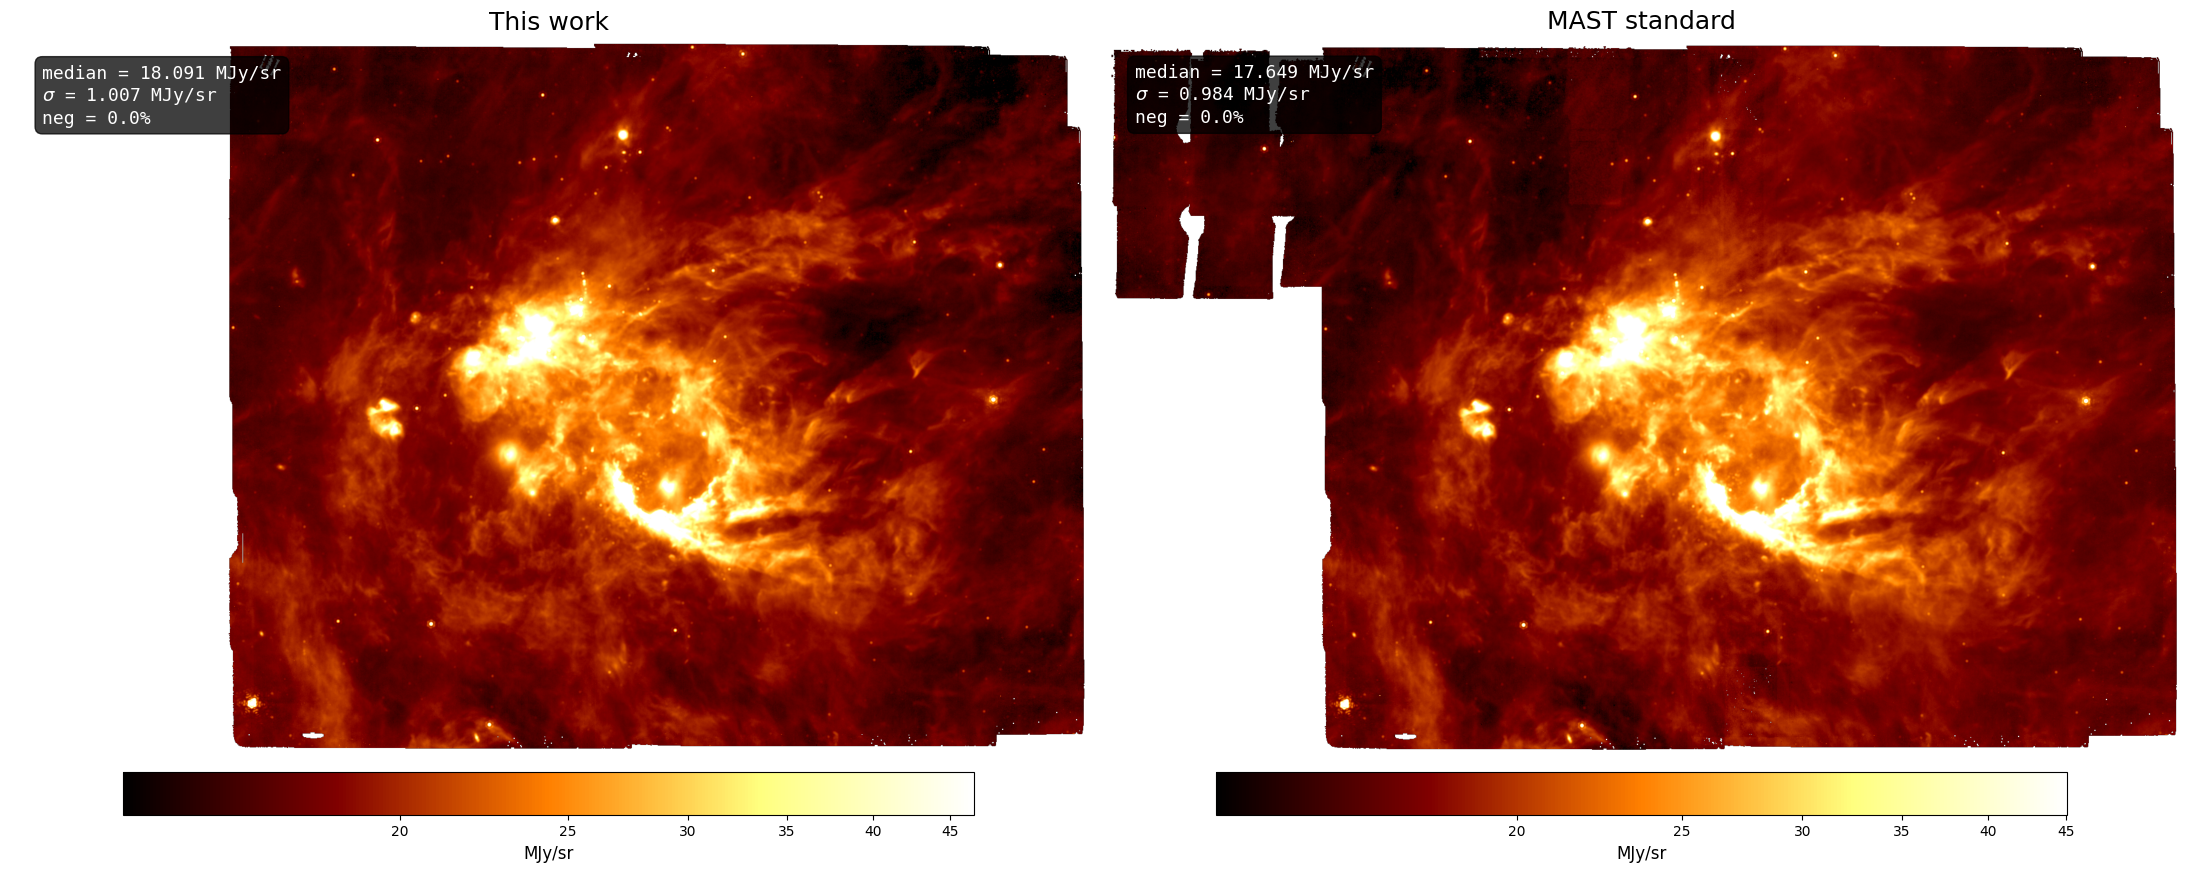

This work: σ = 1.007 MJy/sr
MAST:      σ = 0.984 MJy/sr


In [9]:
mast_i2d = sorted(glob.glob(f'{mast_dir}/*_i2d.fits'))
if mast_i2d:
    mast_sci = load_mosaic(mast_i2d[0])
    m_mast = get_stats(mast_sci)
    plot_comparison(final_sci, mast_sci,
                    'This work', 'MAST standard',
                    f'{FILT}_comparison.png', fig_dir=fig_dir,
                    stats1=stats_label(*m_ours), stats2=stats_label(*m_mast))
    print(f'This work: σ = {m_ours[1]:.3f} MJy/sr')
    print(f'MAST:      σ = {m_mast[1]:.3f} MJy/sr')
else:
    print('No MAST reference found')

## 8. Source Catalog

Catalog: 150 sources


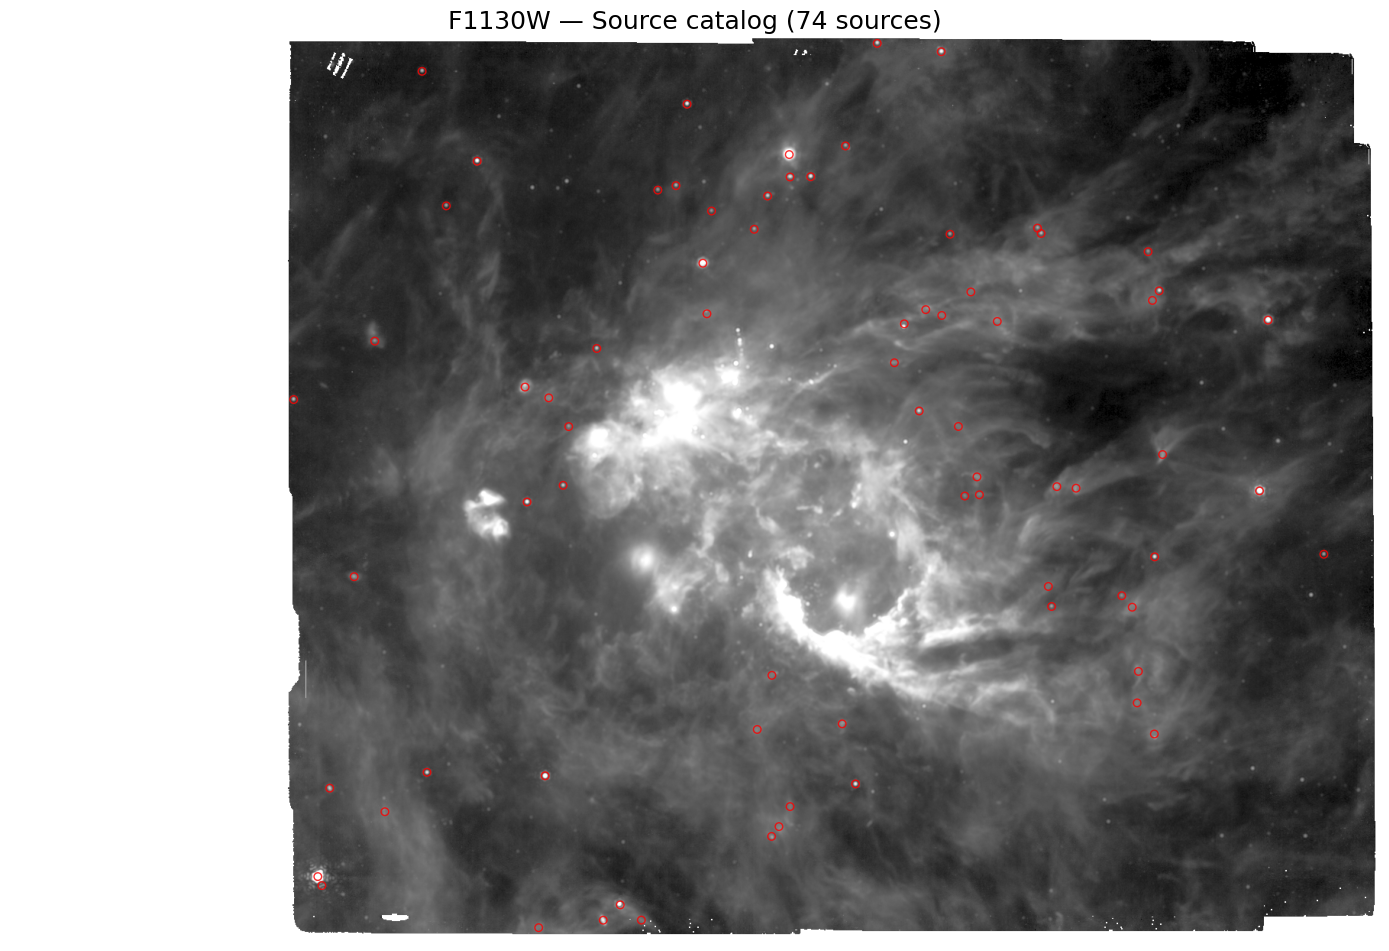

In [10]:
plot_source_catalog(stage3, final_sci, FILT, fig_dir=fig_dir, dpi=FIG_DPI)

## 9. Summary

In [11]:
print_pipeline_summary(
    TARGET, PROGRAM, FILT, m_ours=m_ours,
    tile1_shifts=TILE1_SHIFTS, tile2_shifts=TILE2_SHIFTS,
    ipc_skip=IPC_SKIP, jump_threshold=JUMP_THRESHOLD,
    lyot_row=LYOT_ROW, lyot_col=LYOT_COL,
    pixel_scale=PIXEL_SCALE, pixfrac=PIXFRAC, kernel=KERNEL,
    tweakreg=TWEAKREG, skymatch=SKYMATCH,
    sky_subtract=SKY_SUBTRACT, outlier_det=OUTLIER_DET)

  SMC-SW-Bar-3 (GO-5952) — F1130W

  Result:
    median = 18.091 MJy/sr
    σ = 1.007 MJy/sr

  WCS shifts:
    Tile 1: [-0.1674, -0.1364]
    Tile 2: [-0.1584, -0.1352]

  Stage 1:
    IPC:              SKIP
    Jump threshold:   5.0σ

  Lyot flag: row>700, col<310

  Stage 3:
    Pixel scale:      0.11 arcsec/pix
    Pixfrac:          1.0
    Kernel:           square
    Tweakreg:         OFF
    Skymatch:         OFF
    Sky subtract:     OFF
    Outlier det:      ON
